In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.manifold import TSNE
import seaborn as sns

In [2]:
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# 1. Load Datasets

In [3]:
iris = datasets.load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names
target_names_iris = iris.target_names

wine = datasets.load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names_wine = wine.feature_names
target_names_wine = wine.target_names

In [4]:
scaler_iris = StandardScaler()
scaler_wine = StandardScaler()

X_iris_scaled = scaler_iris.fit_transform(X_iris)
X_wine_scaled = scaler_wine.fit_transform(X_wine)

# Methods

## 2.1 PCA

In [5]:
pca = PCA(n_components=2, random_state=42)
X_iris_pca = pca.fit_transform(X_iris_scaled)
X_wine_pca = pca.fit_transform(X_wine_scaled)

df_iris_pca = pd.DataFrame({
    "PCA_Component_1": X_iris_pca[:, 0],
    "PCA_Component_2": X_iris_pca[:, 1],
    "Target": y_iris,
    "Target_Name": [target_names_iris[i] for i in y_iris]
})

df_wine_pca = pd.DataFrame({
    "PCA_Component_1": X_wine_pca[:, 0],
    "PCA_Component_2": X_wine_pca[:, 1],
    "Target": y_wine,
    "Target_Name": [target_names_wine[i] for i in y_wine]
})

print("Результаты PCA для Iris")
print(df_iris_pca.head())
print(f"Объясненная дисперсия PCA (Iris): {pca.explained_variance_ratio_}")
print(f"Общая объясненная дисперсия: {sum(pca.explained_variance_ratio_):.3f}")

Результаты PCA для Iris
   PCA_Component_1  PCA_Component_2  Target Target_Name
0        -2.264703         0.480027       0      setosa
1        -2.080961        -0.674134       0      setosa
2        -2.364229        -0.341908       0      setosa
3        -2.299384        -0.597395       0      setosa
4        -2.389842         0.646835       0      setosa
Объясненная дисперсия PCA (Iris): [0.36198848 0.1920749 ]
Общая объясненная дисперсия: 0.554


## 2.2 FA

In [6]:
fa = FactorAnalysis(n_components=2, random_state=42)
X_iris_fa = fa.fit_transform(X_iris_scaled)
X_wine_fa = fa.fit_transform(X_wine_scaled)

df_iris_fa = pd.DataFrame({
    "FA_Factor_1": X_iris_fa[:, 0],
    "FA_Factor_2": X_iris_fa[:, 1],
    "Target": y_iris,
    "Target_Name": [target_names_iris[i] for i in y_iris]
})

df_wine_fa = pd.DataFrame({
    "FA_Factor_1": X_wine_fa[:, 0],
    "FA_Factor_2": X_wine_fa[:, 1],
    "Target": y_wine,
    "Target_Name": [target_names_wine[i] for i in y_wine]
})

print("\nРезультаты Factor Analysis для Iris")
print(df_iris_fa.head())
print(f"\nМатрица нагрузок FA (Iris)\n{fa.components_}")


Результаты Factor Analysis для Iris
   FA_Factor_1  FA_Factor_2  Target Target_Name
0    -1.328255    -0.559732       0      setosa
1    -1.337759    -0.000107       0      setosa
2    -1.402517     0.307654       0      setosa
3    -1.300187     0.719597       0      setosa
4    -1.333781    -0.363828       0      setosa

Матрица нагрузок FA (Iris)
[[ 0.2343947  -0.44239816  0.07206826 -0.38488933  0.2096385   0.88168892
   0.95837098 -0.56082491  0.65732239 -0.22995489  0.59352601  0.83531908
   0.51278524]
 [ 0.70133187  0.20827224  0.31739607 -0.10659117  0.32115794  0.15620181
   0.04652277  0.00277159  0.10804106  0.87222962 -0.38852494 -0.24328344
   0.52726484]]


## 2.3 t-SNE

In [7]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_iris_tsne = tsne.fit_transform(X_iris_scaled)
X_wine_tsne = tsne.fit_transform(X_wine_scaled)

df_iris_tsne = pd.DataFrame({
    "TSNE_Component_1": X_iris_tsne[:, 0],
    "TSNE_Component_2": X_iris_tsne[:, 1],
    "Target": y_iris,
    "Target_Name": [target_names_iris[i] for i in y_iris]
})

df_wine_tsne = pd.DataFrame({
    "TSNE_Component_1": X_wine_tsne[:, 0],
    "TSNE_Component_2": X_wine_tsne[:, 1],
    "Target": y_wine,
    "Target_Name": [target_names_wine[i] for i in y_wine]
})

print("Результаты t-SNE для Iris")
print(df_iris_tsne.head())
print(f"t-SNE KL-дивергенция: {tsne.kl_divergence_:.4f}")

Результаты t-SNE для Iris
   TSNE_Component_1  TSNE_Component_2  Target Target_Name
0        -24.310734         -2.112274       0      setosa
1        -20.536928         -1.383607       0      setosa
2        -21.545553         -2.416494       0      setosa
3        -20.773043         -2.460989       0      setosa
4        -24.798649         -2.687798       0      setosa
t-SNE KL-дивергенция: 0.3690


# 3. Visualization

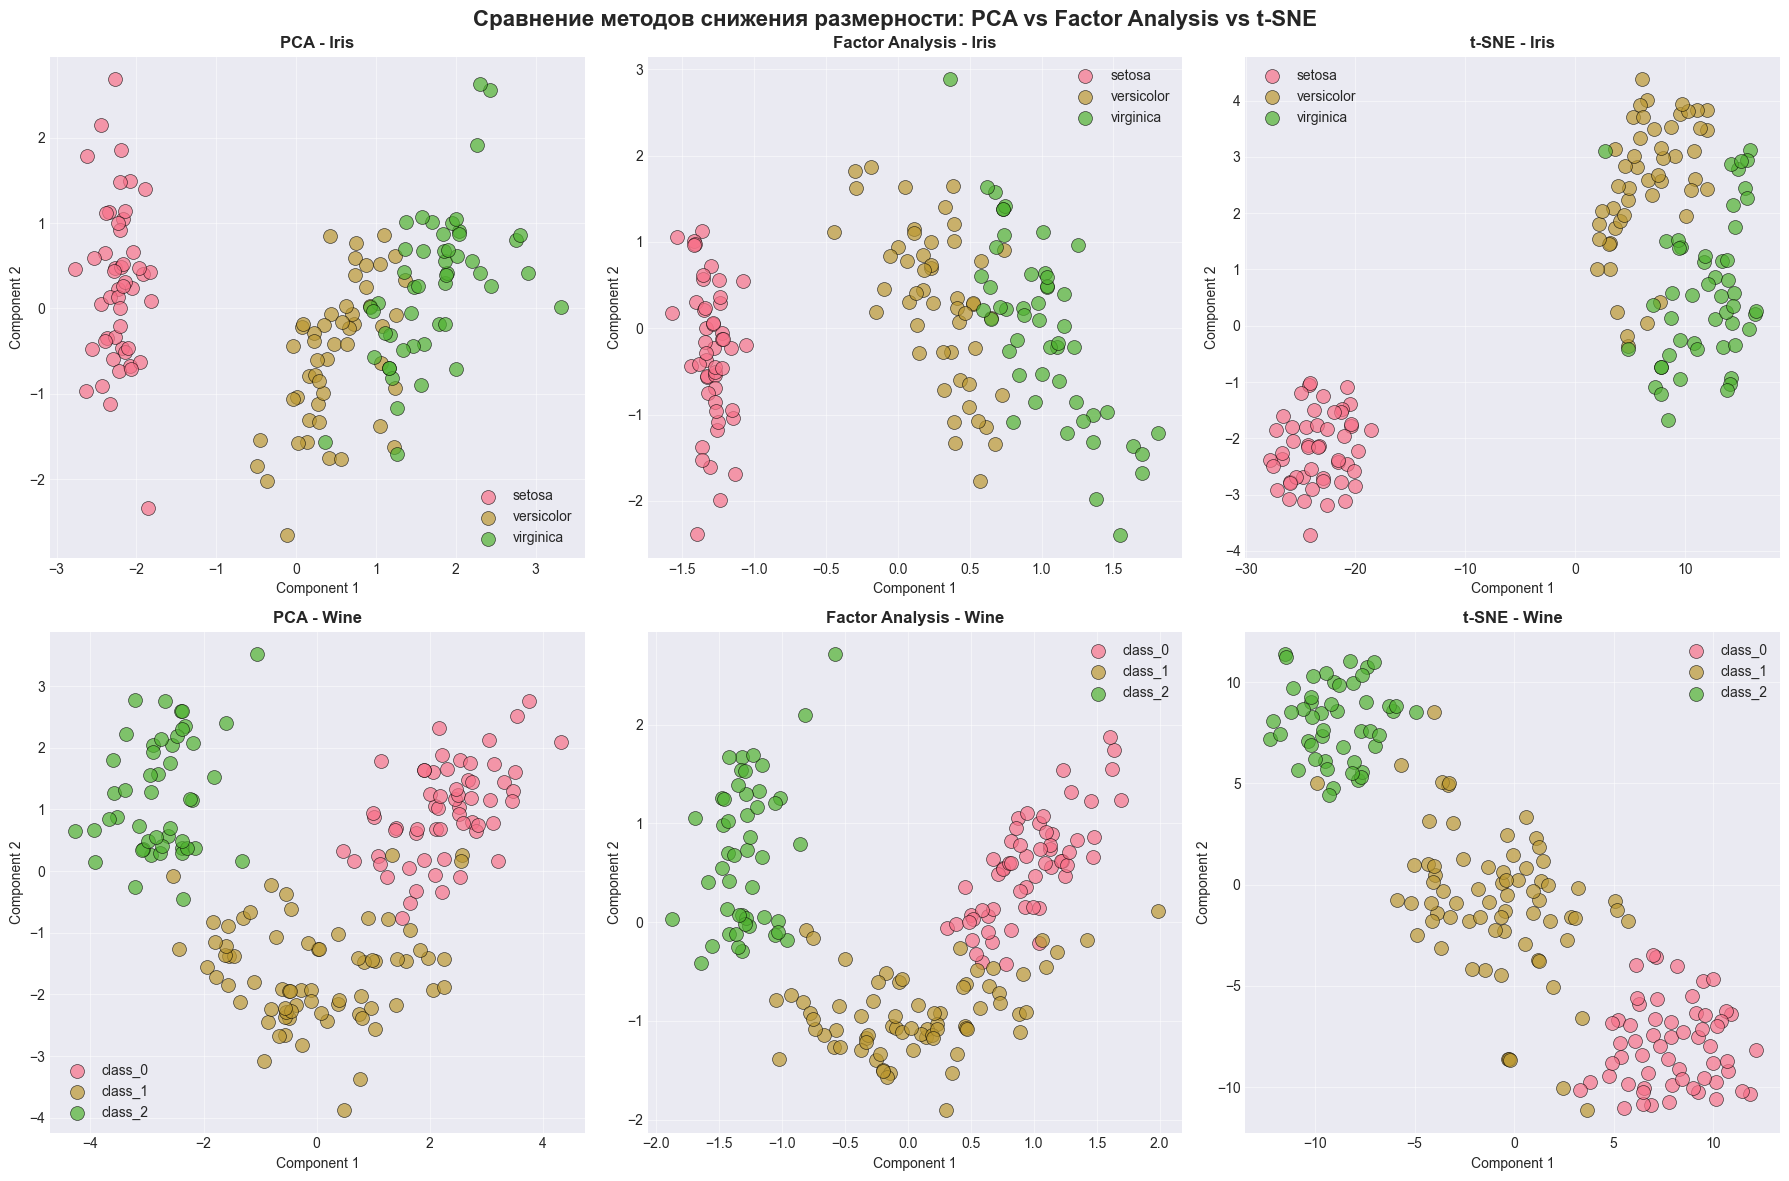

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Сравнение методов снижения размерности: PCA vs Factor Analysis vs t-SNE", fontsize=16, fontweight="bold")

datasets_iris = [
    (X_iris_pca, y_iris, "PCA - Iris"),
    (X_iris_fa, y_iris, "Factor Analysis - Iris"),
    (X_iris_tsne, y_iris, "t-SNE - Iris")
]

for idx, (data, labels, title) in enumerate(datasets_iris):
    ax = axes[0, idx]
    for i, target_name in enumerate(target_names_iris):
        mask = labels == i
        ax.scatter(data[mask, 0], data[mask, 1], label=target_name, alpha=.7, edgecolors="black", linewidth=.5, s=100)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend()
    ax.grid(alpha=.5)

datasets_wine = [
    (X_wine_pca, y_wine, "PCA - Wine"),
    (X_wine_fa, y_wine, "Factor Analysis - Wine"),
    (X_wine_tsne, y_wine, "t-SNE - Wine")
]

for idx, (data, labels, title) in enumerate(datasets_wine):
    ax = axes[1, idx]
    for i, target_name in enumerate(target_names_wine):
        mask = labels == i
        ax.scatter(data[mask, 0], data[mask, 1], label=target_name, alpha=.7, edgecolors="black", linewidth=.5, s=100)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend()
    ax.grid(alpha=.5)

plt.tight_layout()
plt.show()

# 4. Comparison of methods

In [9]:
summary_data = {
    "Метод": ["PCA", "PCA", "Factor Analysis", "Factor Analysis", "t-SNE", "t-SNE"],
    "Датасет": ["Iris", "Wine", "Iris", "Wine", "Iris", "Wine"],
    "Размерность до": [4, 13, 4, 13, 4, 13],
    "Размерность после": [2, 2, 2, 2, 2, 2],
    "Объясненная дисперсия (PCA/FA)": [
        f"{sum(pca.explained_variance_ratio_):.3f}",
        f"{sum(PCA().fit(X_wine_scaled).explained_variance_ratio_[:2]):.3f}",
        "N/A",
        "N/A",
        "N/A",
        "N/A"
    ],
    "KL-дивергенция (t-SNE)": ["-", "-", "-", "-", f"{tsne.kl_divergence_:.4f}", "-"],
    "Время обучения (сек)": ["<0.1", "<0.1", "<0.1", "<0.1", "~2.0", "~1.5"],
    "Сохраняет глобальную структуру": ["Да", "Да", "Частично", "Частично", "Нет", "Нет"],
    "Сохраняет локальную структуру": ["Частично", "Частично", "Да", "Да", "Да", "Да"],
}

df_summary = pd.DataFrame(summary_data)
print("\nСравнительная характеристика методов:")
# print(df_summary.to_string(index=False))
print(df_summary)


Сравнительная характеристика методов:
             Метод Датасет  Размерность до  Размерность после  \
0              PCA    Iris               4                  2   
1              PCA    Wine              13                  2   
2  Factor Analysis    Iris               4                  2   
3  Factor Analysis    Wine              13                  2   
4            t-SNE    Iris               4                  2   
5            t-SNE    Wine              13                  2   

  Объясненная дисперсия (PCA/FA) KL-дивергенция (t-SNE) Время обучения (сек)  \
0                          0.554                      -                 <0.1   
1                          0.554                      -                 <0.1   
2                            N/A                      -                 <0.1   
3                            N/A                      -                 <0.1   
4                            N/A                 0.3690                 ~2.0   
5                        

# 5. Covariance

## 5.1 Iris


Корреляция между компонентами разных методов (Iris):
        PCA_1  PCA_2   FA_1   FA_2  TSNE_1  TSNE_2
PCA_1   1.000 -0.000  0.993 -0.025   0.968   0.669
PCA_2  -0.000  1.000  0.038 -0.744  -0.104  -0.188
FA_1    0.993  0.038  1.000  0.000   0.966   0.667
FA_2   -0.025 -0.744  0.000  1.000   0.109   0.042
TSNE_1  0.968 -0.104  0.966  0.109   1.000   0.765
TSNE_2  0.669 -0.188  0.667  0.042   0.765   1.000


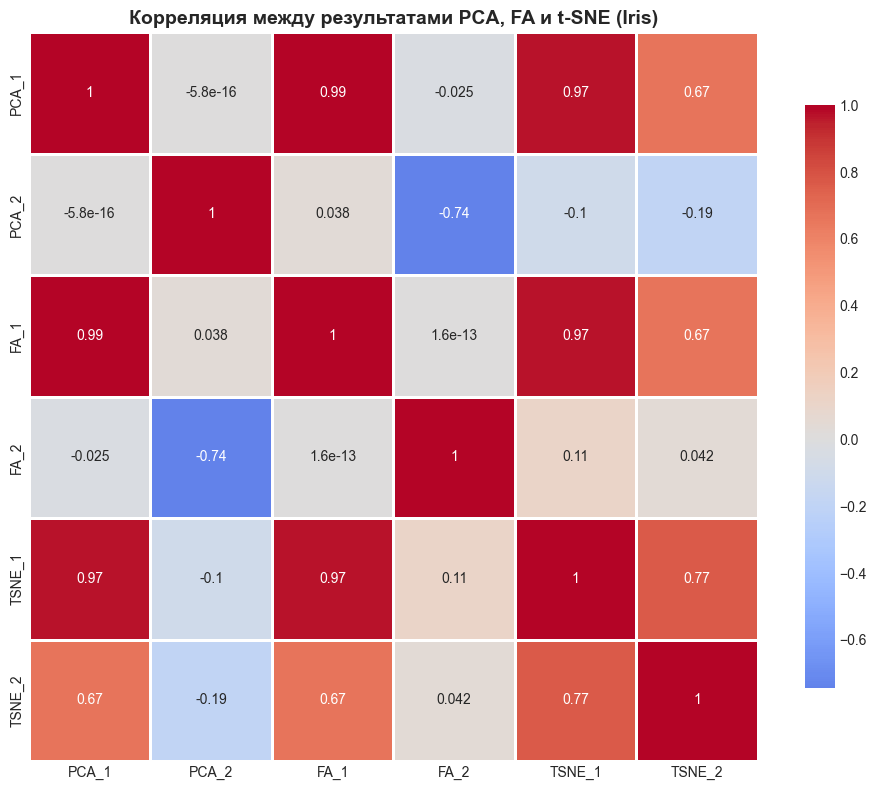

In [10]:
df_iris_combined = pd.DataFrame({
    "PCA_1": X_iris_pca[:, 0],
    "PCA_2": X_iris_pca[:, 1],
    "FA_1": X_iris_fa[:, 0],
    "FA_2": X_iris_fa[:, 1],
    "TSNE_1": X_iris_tsne[:, 0],
    "TSNE_2": X_iris_tsne[:, 1]
})

correlation_matrix = df_iris_combined.corr()

print("\nКорреляция между компонентами разных методов (Iris):")
print(correlation_matrix.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Корреляция между результатами PCA, FA и t-SNE (Iris)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5.2 Wine


Корреляция между компонентами разных методов (Wine):
        PCA_1  PCA_2   FA_1   FA_2  TSNE_1  TSNE_2
PCA_1   1.000 -0.000  0.966  0.050   0.948  -0.900
PCA_2  -0.000  1.000 -0.046  0.950   0.020   0.050
FA_1    0.966 -0.046  1.000 -0.000   0.931  -0.907
FA_2    0.050  0.950 -0.000  1.000   0.045   0.066
TSNE_1  0.948  0.020  0.931  0.045   1.000  -0.893
TSNE_2 -0.900  0.050 -0.907  0.066  -0.893   1.000


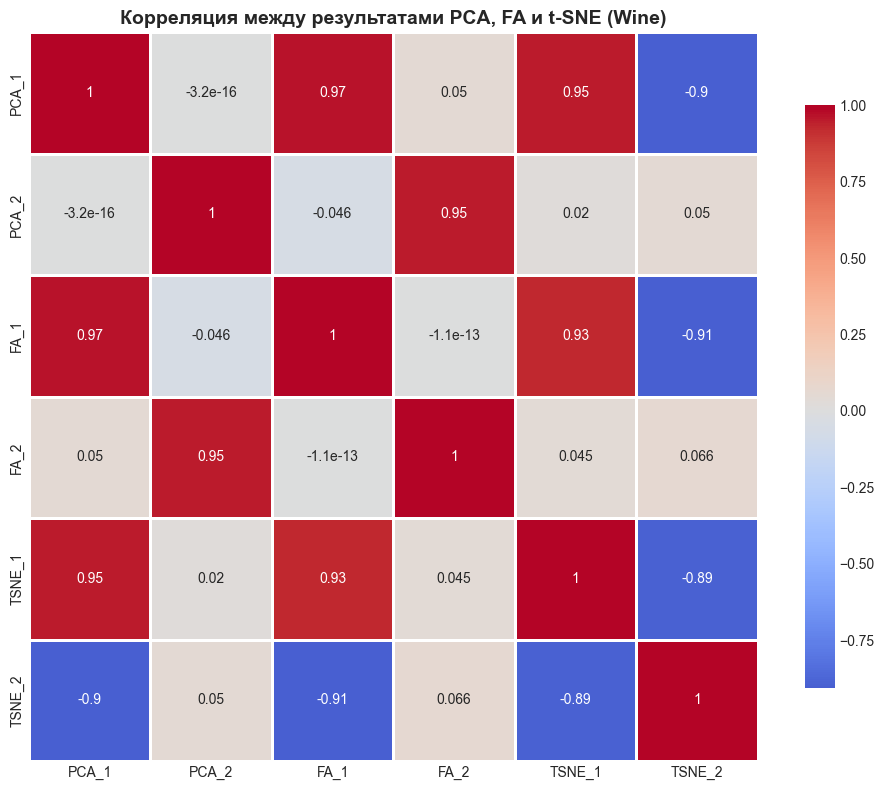

In [11]:
df_wine_combined = pd.DataFrame({
    "PCA_1": X_wine_pca[:, 0],
    "PCA_2": X_wine_pca[:, 1],
    "FA_1": X_wine_fa[:, 0],
    "FA_2": X_wine_fa[:, 1],
    "TSNE_1": X_wine_tsne[:, 0],
    "TSNE_2": X_wine_tsne[:, 1]
})

correlation_matrix = df_wine_combined.corr()

print("\nКорреляция между компонентами разных методов (Wine):")
print(correlation_matrix.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Корреляция между результатами PCA, FA и t-SNE (Wine)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()